<h1>Train — ConvNeXt-Tiny</h1>

Trains and evaluates ConvNeXt-Tiny using the tuned hyperparameters from `ARCH_HYPERPARAMS["convnext_tiny"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): Fisantekraal
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1814 | Val: 441 | Test: 252


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["convnext_tiny"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"ConvNeXt-Tiny: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

ConvNeXt-Tiny: micro batch = 16, accumulation steps = 2 (effective batch size ≈ 32, tuned value = 24)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with ConvNeXt-Tiny)
# ---------------------------------------------------------
model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)

model.avgpool = nn.AdaptiveMaxPool2d(1)

in_f = model.classifier[2].in_features
model.classifier[2] = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

# criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
criterion = FocalLoss(weight=class_weights_arch, gamma=2.0)

optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)

scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[ConvNeXt-Tiny] Using gradient accumulation: 2 micro-batches per optimizer step (effective batch size ≈ micro_batch x 2).


[ConvNeXt-Tiny] Epoch   1/100 | LR: 5.00e-05 | train loss 0.3759 acc 0.175 | val loss 0.2312 acc 0.308 *


[ConvNeXt-Tiny] Epoch   2/100 | LR: 5.00e-05 | train loss 0.1786 acc 0.545 | val loss 0.0964 acc 0.689 *


[ConvNeXt-Tiny] Epoch   3/100 | LR: 5.00e-05 | train loss 0.0879 acc 0.727 | val loss 0.1006 acc 0.757


[ConvNeXt-Tiny] Epoch   4/100 | LR: 5.00e-05 | train loss 0.0727 acc 0.782 | val loss 0.0758 acc 0.807 *


...

[ConvNeXt-Tiny] Epoch  11/100 | LR: 5.00e-05 | train loss 0.0203 acc 0.904 | val loss 0.1245 acc 0.837


[ConvNeXt-Tiny] Epoch  12/100 | LR: 5.00e-05 | train loss 0.0166 acc 0.906 | val loss 0.0892 acc 0.828


[ConvNeXt-Tiny] Epoch  13/100 | LR: 5.00e-05 | train loss 0.0249 acc 0.907 | val loss 0.1091 acc 0.873


[ConvNeXt-Tiny] Epoch  14/100 | LR: 5.00e-05 | train loss 0.0156 acc 0.918 | val loss 0.1388 acc 0.850


[ConvNeXt-Tiny] Epoch  15/100 | LR: 5.00e-06 | train loss 0.0203 acc 0.915 | val loss 0.1380 acc 0.848

[ConvNeXt-Tiny] No val loss improvement for 10 epochs — stopping early at epoch 15.

[ConvNeXt-Tiny] Restored best checkpoint (val loss = 0.0646)


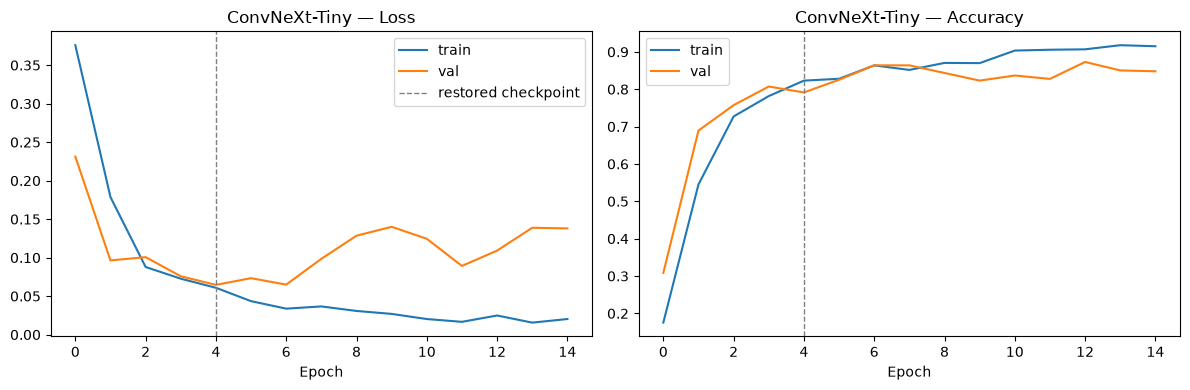

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "ConvNeXt-Tiny", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "ConvNeXt-Tiny")

## Evaluate on the test set

[ConvNeXt-Tiny] Test accuracy: 0.603


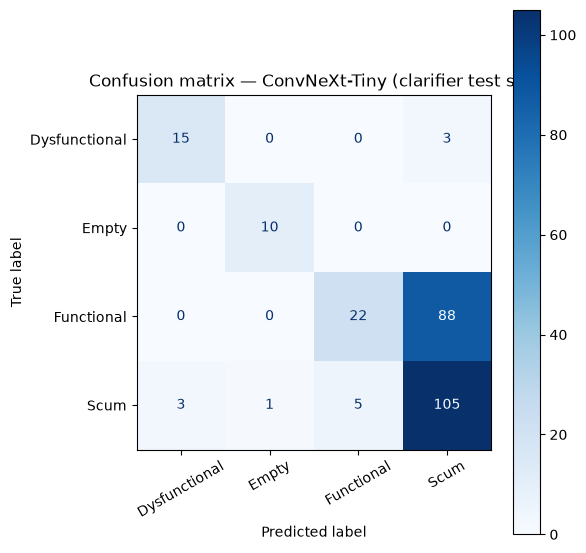

               precision    recall  f1-score   support

Dysfunctional      0.833     0.833     0.833        18
        Empty      0.909     1.000     0.952        10
   Functional      0.815     0.200     0.321       110
         Scum      0.536     0.921     0.677       114

     accuracy                          0.603       252
    macro avg      0.773     0.739     0.696       252
 weighted avg      0.694     0.603     0.544       252



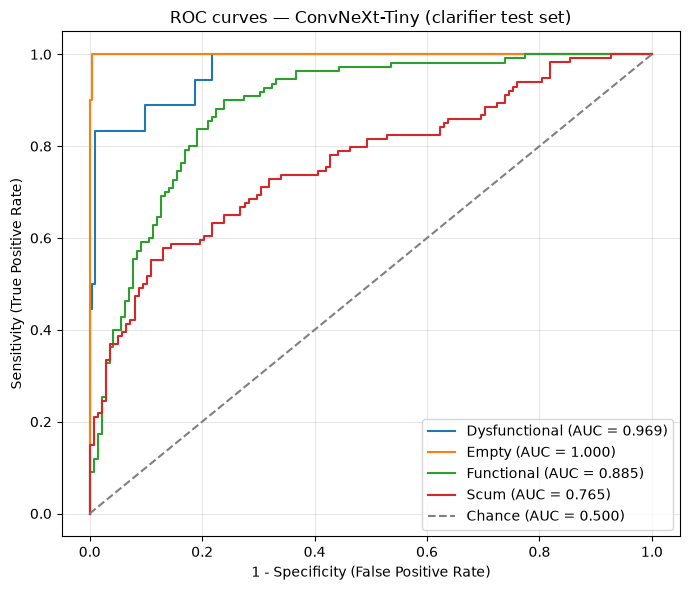

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.969
  Empty          : 1.000
  Functional     : 0.885
  Scum           : 0.765

Mean AUC (over 4/4 classes with test examples): 0.905


(np.float64(0.6031746031746031),
 {'Dysfunctional': 0.9688983855650523,
  'Empty': 0.9995867768595041,
  'Functional': 0.8848911651728554,
  'Scum': 0.7646834477498093})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "ConvNeXt-Tiny", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("ConvNeXt-Tiny", "convnext_tiny")

Saved results to ../results/results_clarifier_convnext_tiny_Fisantekraal.pkl
Saved model weights to ../models/clarifier_convnext_tiny_cnn.pt
